# Tsukuba research-building microgrid

This notebook shows the one released system and its per-second files, loads two days, and plots battery SOC. It makes no diagnosis.

## 1. Released units

This step lists what `systems('tsukuba')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('tsukuba')
display(released)

,unit,raw_files,cleaned_files,first_day,last_day
0,tsukuba,118,119,2015-01-01,2018-04-24


The release is one building microgrid with one lead-acid battery. Raw and publisher-cleaned per-second files are both released.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('tsukuba', start='2016-03-01', end='2016-03-02')
print(frame.shape)
display(frame.head())

(172800, 12)


,battery_active_power,battery_dc_voltage,battery_dc_current,grid_point_voltage,grid_point_active_power,pv_active_power,battery_active_power_setpoint,battery_soc,pv1_active_power,pv2_active_power,pv3_active_power,pv4_active_power
time,,,,,,,,,,,,
2016-03-01 00:00:00,-0.750,347.061249,0.0625,6680.25,628.799988,0.0,0.0,95.0,0.0,0.0,0.0,0.0
2016-03-01 00:00:01,-0.750,345.420013,-0.2500,6680.25,583.200012,0.0,0.0,95.0,0.0,0.0,0.0,0.0
2016-03-01 00:00:02,-0.750,345.420013,-0.2500,6680.25,583.200012,0.0,0.0,95.0,0.0,0.0,0.0,0.0
2016-03-01 00:00:03,-0.750,345.167511,-0.5625,6682.50,592.799988,0.0,0.0,95.0,0.0,0.0,0.0,0.0
2016-03-01 00:00:04,-0.825,346.556244,-0.2500,6678.00,583.200012,0.0,0.0,95.0,0.0,0.0,0.0,0.0


Two days at one row per second. Column names are English translations of the Japanese headers, and units are kept in the frame's attributes.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['battery_active_power', 'battery_dc_voltage', 'battery_dc_current', 'battery_soc', 'pv_active_power']].describe().T)

,count,mean,std,min,25%,50%,75%,max
battery_active_power,172800.0,-1.110385,10.188213,-58.650002,-0.825000,-0.750000,-0.675000,62.775002
battery_dc_voltage,172800.0,346.229277,11.888349,317.013763,341.506256,344.662506,345.924988,404.631256
battery_dc_current,172800.0,0.014328,29.522868,-143.687500,-0.562500,0.062500,0.375000,201.000000
battery_soc,172800.0,93.461343,1.667574,90.839996,91.470001,94.120003,95.000000,95.000000
pv_active_power,172800.0,16.135379,22.321207,-1.680000,0.000000,0.000000,36.959999,62.880001


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

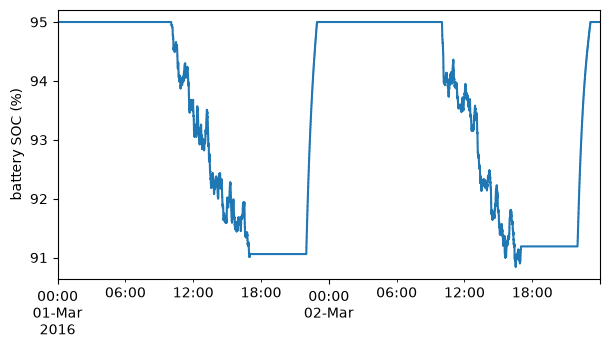

In [4]:
ax = frame['battery_soc'].plot(figsize=(7, 3.5))
ax.set_xlabel('')
ax.set_ylabel('battery SOC (%)')
plt.show()

Over two days battery SOC stays between 91 and 95 percent, discharging during the working day and recharging in the evening.